In [20]:
# %pip install polars

In [21]:
import pandas as pd
import polars as pl
import numpy as np
import time
import matplotlib.pyplot as plt

In [22]:
n_rows = 20_000_000
csv_path = 'big_data_csv'
df = pd.DataFrame({
    'id': np.arange(n_rows),
    'category': np.random.choice(['A', 'B', 'C', 'D']),
    'value1': np.random.rand(n_rows)*100,
    'value2': np.random.rand(n_rows)*1000
})

df.to_csv(csv_path, index=False)

In [23]:
results = []
def measure_time(label, func):
    start = time.time()
    result = func()
    duration = time.time() - start
    results.append((label, duration))
    return result

In [24]:
df_pd = measure_time('Pandas - read_csv', lambda: pd.read_csv(csv_path))
measure_time('Pandas - filter', lambda: df_pd[df_pd['value1']> 50])
measure_time('Pandas - grouby mean', lambda: df_pd.groupby('category')['value2'].mean())
measure_time('Pandas - add column', lambda: df_pd.assign(value_sum = df_pd['value1'] + df_pd['value2']))

,id,category,value1,value2,value_sum
0,0,B,49.594567,325.839077,375.433644
1,1,B,10.526428,525.540303,536.066731
2,2,B,74.069551,401.200539,475.270090
3,3,B,54.132406,589.050372,643.182778
4,4,B,95.994144,146.236517,242.230660
...,...,...,...,...,...
19999995,19999995,B,86.438665,325.685012,412.123677
19999996,19999996,B,21.944618,503.279811,525.224429
19999997,19999997,B,46.707643,76.847213,123.554856
19999998,19999998,B,49.581959,5.874926,55.456886


In [25]:
df_pl = measure_time('Polars - read_csv', lambda: pl.read_csv(csv_path))
measure_time('Polars - filter', lambda: df_pl.filter(pl.col('value1') > 50))
measure_time('Polars - groupby mean', lambda: df_pl.group_by('category').agg(pl.col('value2').mean()))
measure_time('Polars - add column', lambda: df_pl.with_columns((pl.col('value1') + pl.col('value2')).alias('value_sum')))

id,category,value1,value2,value_sum
i64,str,f64,f64,f64
0,"""B""",49.594567,325.839077,375.433644
1,"""B""",10.526428,525.540303,536.066731
2,"""B""",74.069551,401.200539,475.27009
3,"""B""",54.132406,589.050372,643.182778
4,"""B""",95.994144,146.236517,242.23066
…,…,…,…,…
19999995,"""B""",86.438665,325.685012,412.123677
19999996,"""B""",21.944618,503.279811,525.224429
19999997,"""B""",46.707643,76.847213,123.554856


In [26]:
results

[('Pandas - read_csv', 4.55025315284729),
 ('Pandas - filter', 0.24848008155822754),
 ('Pandas - grouby mean', 0.7441909313201904),
 ('Pandas - add column', 0.3631730079650879),
 ('Polars - read_csv', 1.9703340530395508),
 ('Polars - filter', 0.3562188148498535),
 ('Polars - groupby mean', 0.07098579406738281),
 ('Polars - add column', 0.01170206069946289)]

In [27]:
def run_lazy_pipeline():
    df_lazy = pl.read_csv(csv_path).lazy()
    return (
        df_lazy
        .filter(pl.col('value1') > 50)
        .with_columns((pl.col('value1')+pl.col('value2')).alias('value_sum'))
        .group_by('category')
        .agg(pl.col('value2').mean())
        .collect()
    )

In [28]:
measure_time('Polars Lazy - full pipeline', run_lazy_pipeline)

category,value2
str,f64
"""B""",500.135931


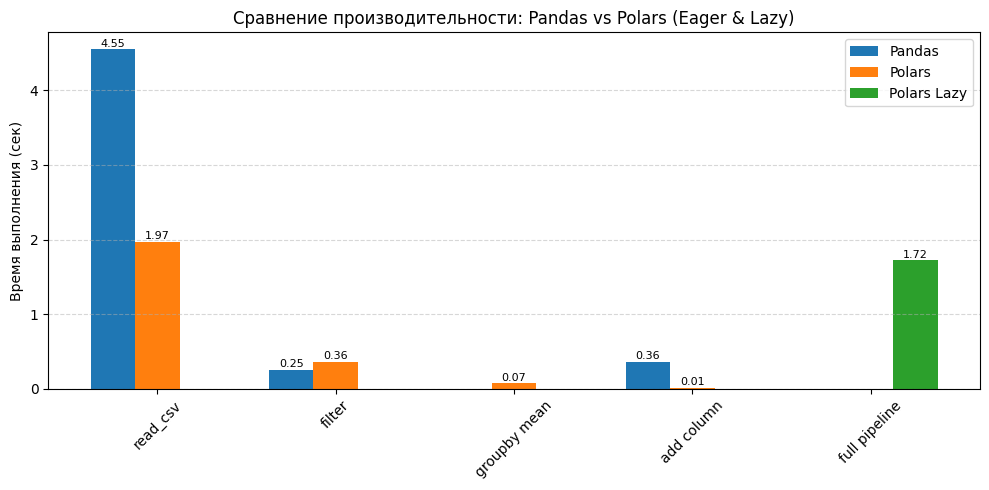

In [29]:
perf_df = pd.DataFrame(results, columns=["Операция", "Время (сек)"])
perf_df["Библиотека"] = perf_df["Операция"].str.split(" - ").str[0]
perf_df["Тип операции"] = perf_df["Операция"].str.split(" - ").str[1]

# Уникальные типы операций, которые хотим отобразить
operation_types = ['read_csv', 'filter', 'groupby mean', 'add column', 'full pipeline']
x = np.arange(len(operation_types))
width = 0.25

# Получение времени выполнения по операциям
def get_times(lib):
    data = perf_df[perf_df["Библиотека"] == lib].set_index("Тип операции")
    return [data.loc[op]["Время (сек)"] if op in data.index else 0 for op in operation_types]

pandas_times = get_times("Pandas")
polars_times = get_times("Polars")
lazy_times = get_times("Polars Lazy")

# Построение группированного графика
plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width, pandas_times, width, label="Pandas")
bars2 = plt.bar(x, polars_times, width, label="Polars")
bars3 = plt.bar(x + width, lazy_times, width, label="Polars Lazy")

# Подписи значений
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

# Настройка графика
plt.xticks(x, operation_types, rotation=45)
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение производительности: Pandas vs Polars (Eager & Lazy)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()